In [ ]:
import os
Dataset_Path="/content/drive/MyDrive/AID"
print(os.listdir(Dataset_Path))

['Safe', 'Unsafe', 'Conditional']


In [1]:
!pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 28.0 MB/s eta 0:00:00


In [2]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt

import optuna
from optuna.samplers import TPESampler
from optuna.pruners  import MedianPruner

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torch.optim.lr_scheduler import CosineAnnealingLR

from torchvision import datasets, transforms, models
from torchvision.models import EfficientNet_B0_Weights

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
IMG_SIZE=224
batch_size= 3
Epochs=10
torch.manual_seed(42)
np.random.seed(42)

In [5]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

In [6]:
#Training transforms (with augmentation)

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),               # rotate by up to 20 degrees
    transforms.ColorJitter(brightness=0.2,
                           contrast=0.2,
                           saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN,     # normalise (REQUIRED for
                         std=IMAGENET_STD),      # pretrained EfficientNet)
])

# Validation transforms (no augmentation)
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Splitting Dataset


In [7]:
DATASET_PATH = "/content/drive/MyDrive/AID"

SEED = 42   # makes the random split reproducible (same result every run)
torch.manual_seed(SEED)
np.random.seed(SEED)

# Load the full dataset twice — one with train transforms, one with val transforms
full_train_data = datasets.ImageFolder(DATASET_PATH, transform=train_transform)
full_val_data   = datasets.ImageFolder(DATASET_PATH, transform=val_transform)

# Creating an 80/20 split
dataset_size  = len(full_train_data)
indices       = np.arange(dataset_size)
np.random.shuffle(indices)

split_point   = int(0.8 * dataset_size)
train_indices = indices[:split_point]
val_indices   = indices[split_point:]

train_dataset = Subset(full_train_data, train_indices)
val_dataset   = Subset(full_val_data,   val_indices)

CLASS_NAMES = full_train_data.classes
NUM_CLASSES = len(CLASS_NAMES)

print(f"   Total images   : {dataset_size}")
print(f"   Training images: {len(train_dataset)}")
print(f"   Validation imgs: {len(val_dataset)}")
print(f"   Classes        : {CLASS_NAMES}")


   Total images   : 6916
   Training images: 5532
   Validation imgs: 1384
   Classes        : ['Conditional', 'Safe', 'Unsafe']


# Displaying Image before Training

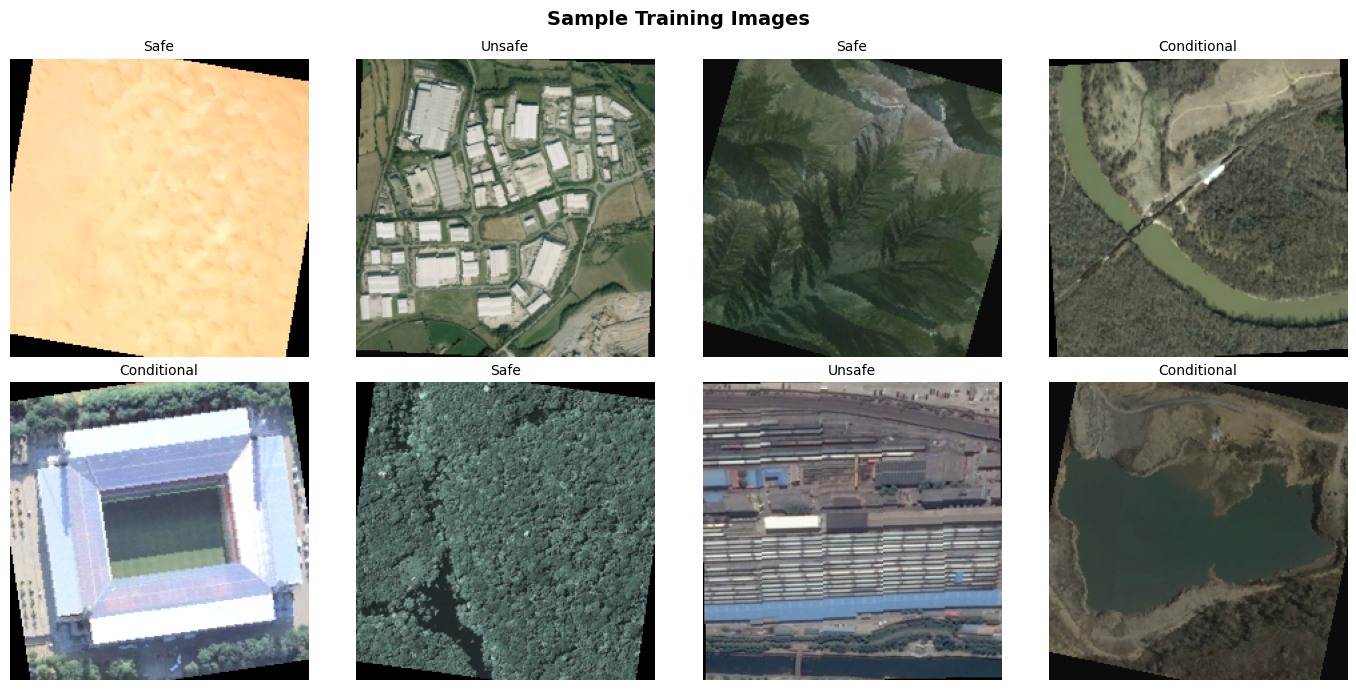

In [8]:
def imshow(tensor, title=""):
    #Display a normalised tensor as an image.
    # Undo normalisation for display
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img  = tensor * std + mean           # reverse normalise
    img  = img.permute(1, 2, 0).numpy() #  Reorder Image : C×H×W → H×W×C
    img  = img.clip(0, 1)               # keep values in [0, 1]
    plt.imshow(img)
    plt.title(title, fontsize=10)
    plt.axis('off')

# Quick loader just for preview (batch of 8)
preview_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
images, labels = next(iter(preview_loader))

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Sample Training Images", fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    plt.sca(ax)
    imshow(images[i], title=CLASS_NAMES[labels[i]])

plt.tight_layout()
plt.show()


# Defining Model

In [9]:
def build_model(dropout_rate=0.3):
    # Loading EfficientNet with pretrained ImageNet weights

    weights = EfficientNet_B0_Weights.DEFAULT
    model   = models.efficientnet_b0(weights=weights)

    # Freezing the model's layers
    for param in model.features.parameters():
        param.requires_grad = False


    in_features = model.classifier[1].in_features   # getting no. of feature in last layer of Transfered model

    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout_rate, inplace=True),
        nn.Linear(in_features, 256),
        nn.SiLU(),
        nn.Dropout(p=dropout_rate / 2),
        nn.Linear(256, NUM_CLASSES),
    )

    return model.to(device)




## Testing Model

In [10]:
# Quick test: build a model and check its output shape
test_model  = build_model()
dummy_input = torch.randn(2, 3, 224, 224).to(device)   # fake batch of 2 images
dummy_out   = test_model(dummy_input)

print(f"   Input shape : {list(dummy_input.shape)}")
print(f"   Output shape: {list(dummy_out.shape)}")
print(f"   Classes     : {CLASS_NAMES}")
del test_model, dummy_input, dummy_out   # free memory

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 177MB/s]


   Input shape : [2, 3, 224, 224]
   Output shape: [2, 3]
   Classes     : ['Conditional', 'Safe', 'Unsafe']


In [11]:


print(f"Train size : {len(train_dataset)}")
print(f"Val size   : {len(val_dataset)}")
print(f"Classes    : {CLASS_NAMES}")


Train size : 5532
Val size   : 1384
Classes    : ['Conditional', 'Safe', 'Unsafe']


# Evaluate Model

In [12]:
# Evaluation function
def evaluate(model, loader):

    model.eval()   # switch to evaluation mode
    correct = 0
    total   = 0

    with torch.no_grad():
        for images, labels in loader:
            images  = images.to(device)
            labels  = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, dim=1)   # pick the class with highest score

            total   += labels.size(0)
            correct += (preds == labels).sum().item()

    return 100.0 * correct / total


# Training Model

In [13]:
def train_one_trial(lr, batch_size, epochs, dropout_rate, trial=None):

    # DataLoader feeds images in batches to the model
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,           # no need to shuffle validation
        num_workers=2,
        pin_memory=True,
    )

    model     = build_model(dropout_rate)
    criterion = nn.CrossEntropyLoss()   # standard loss for multi-class classification

    # optimization
    optimizer = optim.Adam(
        model.classifier.parameters(),   # only the unfrozen head
        lr=lr,
        weight_decay=1e-4,               # L2 regularisation (helps prevent overfitting)
    )

    # Learning rate scheduler gradually reduces learning_rate as training progresses
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    best_val_acc    = 0.0         #stores best accuracy
    best_weights    = copy.deepcopy(model.state_dict())  # snapshot of best model
    patience        = 5     # automatically stop if no improvements for this many epochs
    epochs_no_improve = 0

    train_loss_history = []
    val_acc_history    = []

    for epoch in range(epochs):
        model.train()        # switch to training mode (enables dropout layers)
        running_loss = 0.0

        for images, labels in train_loader:
            images,labels = images.to(device),labels.to(device)

            optimizer.zero_grad()        # clear old gradients

            outputs = model(images)      # forward propogation: images → class scores

            loss=criterion(outputs, labels)  # compare scores to true labels and calculate loss

            loss.backward()              # backward propogation: compute gradients
            optimizer.step()             # update model weights

            running_loss += loss.item()

        scheduler.step()                 # update learning rate accordingly

        epoch_loss = running_loss / len(train_loader)
        val_acc    = evaluate(model, val_loader)

        train_loss_history.append(epoch_loss)
        val_acc_history.append(val_acc)

        print(f"  Epoch [{epoch+1:02d}/{epochs}]  "
              f"Loss: {epoch_loss:.4f}  |  "
              f"Val Accuracy: {val_acc:.2f}%")

        # Saving best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        # Optuna pruning
        # Optuna can kill a bad trial early if it's clearly going nowhere
        if trial is not None:
            trial.report(val_acc, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        # Early stopping
        # If accuracy hasn't improved in 'patience' epochs, stop training
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    # Load the best weights back before returning
    model.load_state_dict(best_weights)
    return best_val_acc, model, train_loss_history, val_acc_history

# Baseline Run

In [15]:
baseline_acc, baseline_model, loss_hist, acc_hist = train_one_trial(lr=0.0005987474910461401,batch_size= 32,epochs= 20,dropout_rate = 0.16820964947491662)

print(f"Baseline run complete! Best val accuracy: {baseline_acc:.2f}%")


  Epoch [01/20]  Loss: 0.4360  |  Val Accuracy: 90.75%
  Epoch [02/20]  Loss: 0.2934  |  Val Accuracy: 92.85%
  Epoch [03/20]  Loss: 0.2661  |  Val Accuracy: 93.42%
  Epoch [04/20]  Loss: 0.2387  |  Val Accuracy: 93.86%
  Epoch [05/20]  Loss: 0.2293  |  Val Accuracy: 93.21%
  Epoch [06/20]  Loss: 0.2054  |  Val Accuracy: 93.57%
  Epoch [07/20]  Loss: 0.1925  |  Val Accuracy: 94.87%
  Epoch [08/20]  Loss: 0.1795  |  Val Accuracy: 94.80%
  Epoch [09/20]  Loss: 0.1686  |  Val Accuracy: 94.87%
  Epoch [10/20]  Loss: 0.1568  |  Val Accuracy: 94.87%
  Epoch [11/20]  Loss: 0.1490  |  Val Accuracy: 94.58%
  Epoch [12/20]  Loss: 0.1511  |  Val Accuracy: 94.73%
Early stopping triggered at epoch 12
Baseline run complete! Best val accuracy: 94.87%


# Plotting Curve on Baseline Run

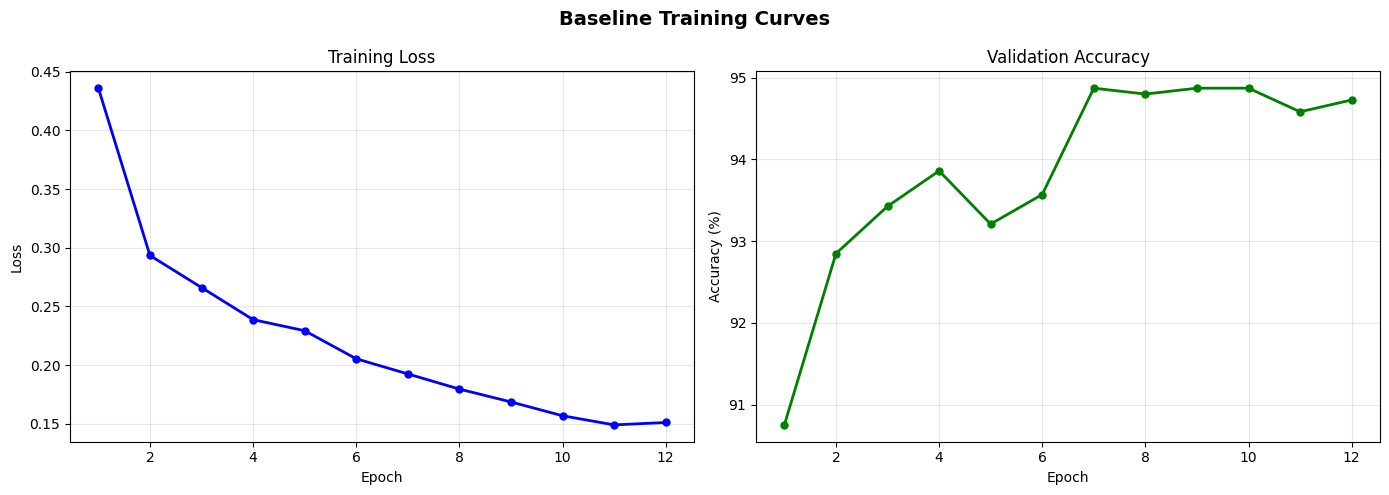

In [16]:
# Ploting training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Baseline Training Curves", fontsize=14, fontweight='bold')

epochs_ran = range(1, len(loss_hist) + 1)

ax1.plot(epochs_ran, loss_hist, 'b-o', linewidth=2, markersize=5)
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_ran, acc_hist, 'g-o', linewidth=2, markersize=5)
ax2.set_title("Validation Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Hypertuning using Optuna  

In [ ]:
def objective(trial):
    lr= trial.suggest_float("lr",1e-5,1e-2,log=True)
    batch_size= trial.suggest_int(  "batch_size",32,64,step=32)
    epochs= trial.suggest_int(  "epochs",5,15,step=5)
    dropout_rate = trial.suggest_float("dropout_rate",0.1,0.5)

    print(f"\nTrial {trial.number+1}:")
    print(f"  lr={lr:.2e} | batch={batch_size} | epochs={epochs} | dropout={dropout_rate:.2f}")

    val_acc, _, _, _ = train_one_trial(lr, batch_size, epochs, dropout_rate, trial) # only wanted validation_accuracy
    return val_acc   # Optuna will try to MAXIMISE this value



## Creating Study and Optimizing

In [ ]:
# MedianPruner: stops bad trials early (saves time)
study = optuna.create_study(
    direction = "maximize",
    sampler   = TPESampler(seed=SEED),
    pruner    = MedianPruner(                  # kill bad trials early
                    n_startup_trials=3,        # wait 3 trials before pruning
                    n_warmup_steps=3))         # wait 3 epochs per trial before pruning

study.optimize(objective, n_trials=7)

print(f"Best validation accuracy : {study.best_value:.2f}%")
print(f"Best hyperparameters:")
for key, val in study.best_params.items():
    print(f"  {key:15s}: {val}")

[I 2026-06-30 16:09:52,835] A new study created in memory with name: no-name-32f95c06-679d-4248-9490-b11fa14aedb3



Trial 1:
  lr=1.33e-04 | batch=64 | epochs=15 | dropout=0.34
  Epoch [01/15]  Loss: 0.7583  |  Val Accuracy: 86.63%
  Epoch [02/15]  Loss: 0.4344  |  Val Accuracy: 89.60%
  Epoch [03/15]  Loss: 0.3698  |  Val Accuracy: 91.04%
  Epoch [04/15]  Loss: 0.3345  |  Val Accuracy: 91.62%
  Epoch [05/15]  Loss: 0.3126  |  Val Accuracy: 91.26%
  Epoch [06/15]  Loss: 0.3079  |  Val Accuracy: 91.91%
  Epoch [07/15]  Loss: 0.3035  |  Val Accuracy: 92.12%
  Epoch [08/15]  Loss: 0.2955  |  Val Accuracy: 92.27%
  Epoch [09/15]  Loss: 0.2897  |  Val Accuracy: 92.27%
  Epoch [10/15]  Loss: 0.2833  |  Val Accuracy: 92.05%
  Epoch [11/15]  Loss: 0.2795  |  Val Accuracy: 92.12%
  Epoch [12/15]  Loss: 0.2753  |  Val Accuracy: 92.27%


[I 2026-06-30 16:30:47,911] Trial 0 finished with value: 92.26878612716763 and parameters: {'lr': 0.0001329291894316216, 'batch_size': 64, 'epochs': 15, 'dropout_rate': 0.3394633936788146}. Best is trial 0 with value: 92.26878612716763.


  Epoch [13/15]  Loss: 0.2734  |  Val Accuracy: 92.27%
Early stopping triggered at epoch 13

Trial 2:
  lr=2.94e-05 | batch=32 | epochs=5 | dropout=0.45
  Epoch [01/5]  Loss: 0.9762  |  Val Accuracy: 75.87%
  Epoch [02/5]  Loss: 0.7745  |  Val Accuracy: 82.15%
  Epoch [03/5]  Loss: 0.6501  |  Val Accuracy: 85.26%
  Epoch [04/5]  Loss: 0.5858  |  Val Accuracy: 85.12%


[I 2026-06-30 16:38:49,295] Trial 1 finished with value: 86.77745664739885 and parameters: {'lr': 2.9380279387035334e-05, 'batch_size': 32, 'epochs': 5, 'dropout_rate': 0.4464704583099741}. Best is trial 0 with value: 92.26878612716763.


...

  Epoch [04/10]  Loss: 0.3553  |  Val Accuracy: 89.88%

Trial 6:
  lr=6.85e-04 | batch=32 | epochs=5 | dropout=0.25
  Epoch [01/5]  Loss: 0.4266  |  Val Accuracy: 90.75%
  Epoch [02/5]  Loss: 0.3078  |  Val Accuracy: 92.63%
  Epoch [03/5]  Loss: 0.2453  |  Val Accuracy: 92.70%
  Epoch [04/5]  Loss: 0.2624  |  Val Accuracy: 92.34%


[I 2026-06-30 17:08:21,637] Trial 5 finished with value: 93.0635838150289 and parameters: {'lr': 0.000684792009557478, 'batch_size': 32, 'epochs': 5, 'dropout_rate': 0.2465447373174767}. Best is trial 3 with value: 95.08670520231213.


  Epoch [05/5]  Loss: 0.2393  |  Val Accuracy: 93.06%

Trial 7:
  lr=2.33e-04 | batch=64 | epochs=5 | dropout=0.31
  Epoch [01/5]  Loss: 0.6291  |  Val Accuracy: 88.29%
  Epoch [02/5]  Loss: 0.3493  |  Val Accuracy: 90.82%
  Epoch [03/5]  Loss: 0.3184  |  Val Accuracy: 91.62%


[I 2026-06-30 17:14:39,004] Trial 6 pruned. 


  Epoch [04/5]  Loss: 0.3132  |  Val Accuracy: 91.98%
Best validation accuracy : 95.09%
Best hyperparameters:
  lr             : 0.00314288089084011
  batch_size     : 32
  epochs         : 5
  dropout_rate   : 0.17336180394137352


In [ ]:
#Best params of model

In [14]:
rbest = study.best_params
final_acc, final_model, final_loss, final_val_acc = train_one_trial(
    lr           = 0.0005987474910461401,
    batch_size   = 32,
    epochs       = 15,
    dropout_rate = 0.17336180394137352
    )

print(f"\n Final model accuracy: {final_acc:.2f}%")


  Epoch [01/15]  Loss: 0.4261  |  Val Accuracy: 90.75%
  Epoch [02/15]  Loss: 0.3019  |  Val Accuracy: 91.76%
  Epoch [03/15]  Loss: 0.2620  |  Val Accuracy: 92.92%
  Epoch [04/15]  Loss: 0.2292  |  Val Accuracy: 92.77%
  Epoch [05/15]  Loss: 0.2272  |  Val Accuracy: 93.57%
  Epoch [06/15]  Loss: 0.1979  |  Val Accuracy: 94.00%
  Epoch [07/15]  Loss: 0.1890  |  Val Accuracy: 93.28%
  Epoch [08/15]  Loss: 0.1833  |  Val Accuracy: 94.65%
  Epoch [09/15]  Loss: 0.1691  |  Val Accuracy: 94.29%
  Epoch [10/15]  Loss: 0.1570  |  Val Accuracy: 94.58%
  Epoch [11/15]  Loss: 0.1557  |  Val Accuracy: 94.51%
  Epoch [12/15]  Loss: 0.1527  |  Val Accuracy: 95.09%
  Epoch [13/15]  Loss: 0.1524  |  Val Accuracy: 94.58%
  Epoch [14/15]  Loss: 0.1602  |  Val Accuracy: 94.80%
  Epoch [15/15]  Loss: 0.1473  |  Val Accuracy: 94.65%

 Final model accuracy: 95.09%


# Plotting Curve

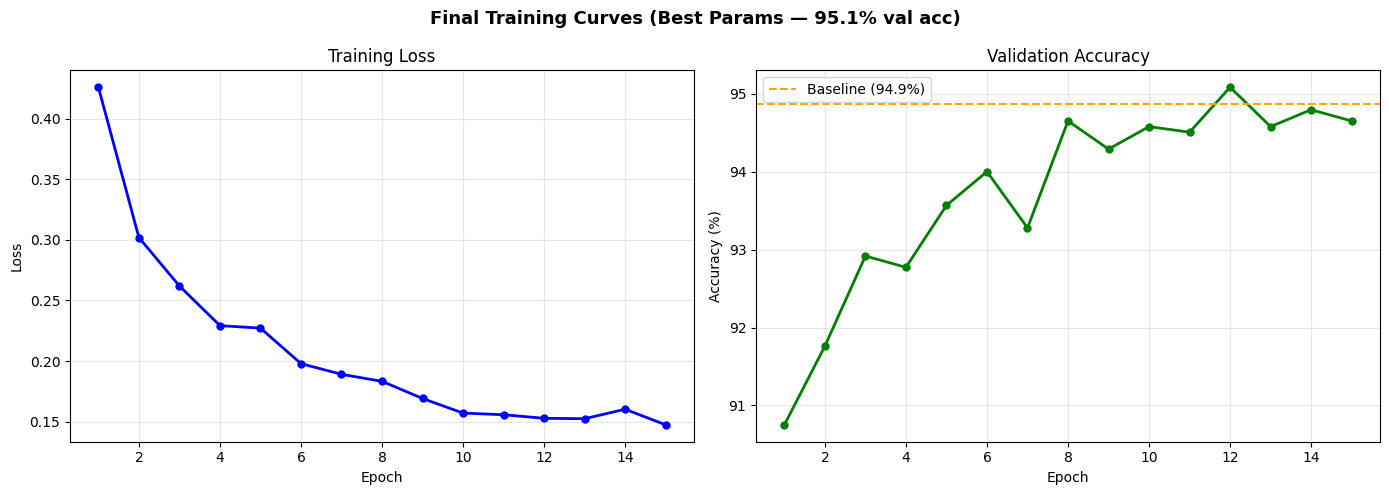

In [17]:
# Ploting final training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Final Training Curves (Best Params — {final_acc:.1f}% val acc)",
             fontsize=13, fontweight='bold')

e = range(1, len(final_loss) + 1)

ax1.plot(e, final_loss, 'b-o', linewidth=2, markersize=5)
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.grid(True, alpha=0.3)

ax2.plot(e, final_val_acc, 'g-o', linewidth=2, markersize=5)
ax2.axhline(y=baseline_acc, color='orange', linestyle='--',
            label=f"Baseline ({baseline_acc:.1f}%)")
ax2.set_title("Validation Accuracy")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#  Detailed Evaluation

              precision    recall  f1-score   support

 Conditional       0.93      0.91      0.92       433
        Safe       0.99      0.97      0.98       464
      Unsafe       0.93      0.97      0.95       487

    accuracy                           0.95      1384
   macro avg       0.95      0.95      0.95      1384
weighted avg       0.95      0.95      0.95      1384



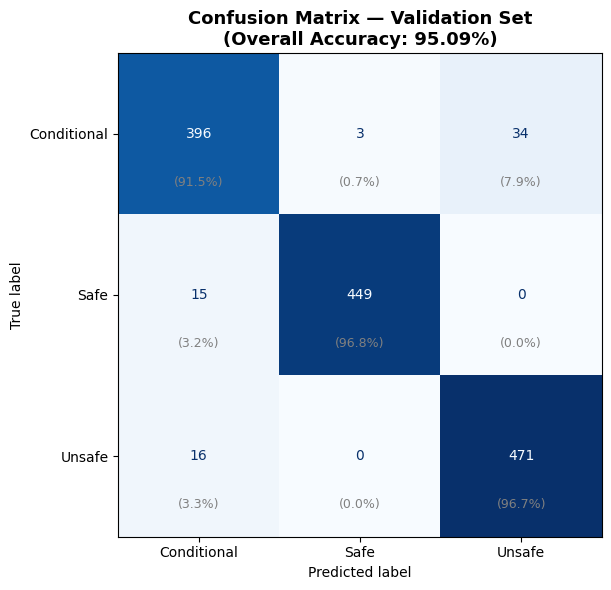

In [18]:
final_model.eval()

all_preds  = []
all_labels = []

val_loader_eval = DataLoader(val_dataset, batch_size=32,
                             shuffle=False, num_workers=2, pin_memory=True)

with torch.no_grad():
    for images, labels in val_loader_eval:
        images  = images.to(device)
        outputs = final_model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())


print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

#Confusion Matrix
cm   = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix — Validation Set\n(Overall Accuracy: {final_acc:.2f}%)",
             fontsize=13, fontweight='bold')

# Add percentage annotations
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        total_in_row = cm[i].sum()
        pct = 100 * cm[i, j] / total_in_row if total_in_row > 0 else 0
        ax.text(j, i + 0.3, f"({pct:.1f}%)",
                ha='center', va='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()


# Saving Model

In [19]:
#Saving just the weights
SAVE_PATH = "/content/drive/MyDrive/drone_landing_model.pth"
torch.save(final_model.state_dict(), SAVE_PATH)
print(f" Model weights saved to: {SAVE_PATH}")




 Model weights saved to: /content/drive/MyDrive/drone_landing_model.pth


# Predicting on a single image

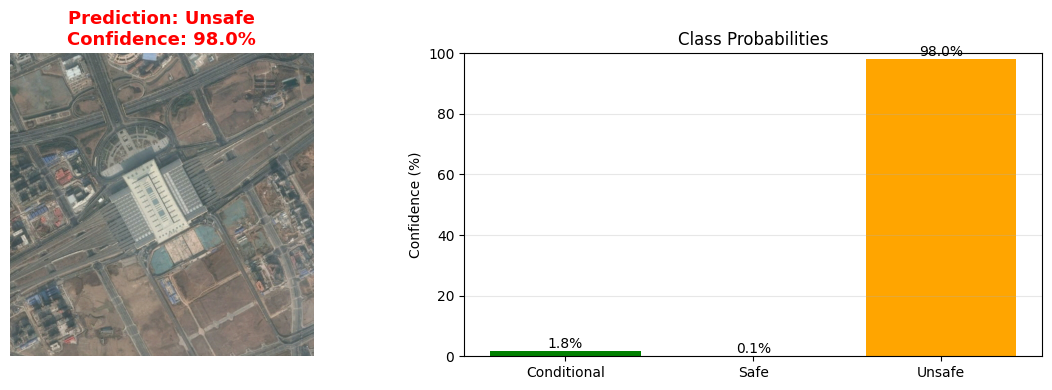

('Unsafe', 98.02537560462952)

In [20]:
from PIL import Image

def predict_image(image_path, model, class_names):

    # Load and preprocess image
    img    = Image.open(image_path).convert("RGB")
    tensor = val_transform(img).unsqueeze(0).to(device)  # add batch dimension

    model.eval()
    with torch.no_grad():
        output     = model(tensor)
        probs      = torch.softmax(output, dim=1)[0]   # convert scores → probabilities
        confidence, pred_idx = torch.max(probs, 0)

    predicted_class = class_names[pred_idx]
    confidence_pct  = 100.0 * confidence.item()

    # Display image with prediction
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.imshow(img)
    color = {"Safe": "green", "Unsafe": "red", "Conditional": "orange"}.get(predicted_class, "blue")
    ax1.set_title(f"Prediction: {predicted_class}\nConfidence: {confidence_pct:.1f}%",
                  color=color, fontsize=13, fontweight='bold')
    ax1.axis('off')

    # Bar chart of all class probabilities
    bars = ax2.bar(class_names, probs.cpu().numpy() * 100,
                   color=['green', 'red', 'orange'][:len(class_names)])
    ax2.set_ylabel("Confidence (%)")
    ax2.set_title("Class Probabilities")
    ax2.set_ylim(0, 100)
    for bar, prob in zip(bars, probs.cpu().numpy()):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{prob*100:.1f}%", ha='center', fontsize=10)
    ax2.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    return predicted_class, confidence_pct


test_image_path = "/content/drive/MyDrive/AID/Unsafe/RailwayStation/railwaystation_1.jpg"
predict_image(test_image_path, final_model, CLASS_NAMES)

